# Phase 5 — Displacement Distributions and Density Estimation

## Session 1: Data intake and statistical foundations

### Aim

This notebook begins the statistical analysis of cell displacements.

The goals of this session are to:

1. load the raw and co-moving trajectory representations;
2. validate that both contain the same underlying observations;
3. reconstruct exact-lag displacement steps for tau = 1, 2, and 4;
4. verify the authoritative step counts;
5. combine the two representations into a tidy analysis table;
6. inspect the empirical distributions of dx and dy before density estimation.

No irreversibility metric is calculated yet.

The purpose of this session is to understand the random variables whose
probability distributions will later be used to compare p(Delta) with
p(-Delta).

In [1]:
import _path
from _path import PROJECT_ROOT

import pandas as pd

from src.steps import (
    compute_steps_multi_tau,
    validate_tracks,
)

RAW_TRACKS_PATH = (
    PROJECT_ROOT
    / "data"
    / "MSC01_tracks_clean.csv"
)

COMOVING_TRACKS_PATH = (
    PROJECT_ROOT
    / "data"
    / "MSC01_tracks_comoving.csv"
)

TAUS = [1, 2, 4]

print("Project root:", PROJECT_ROOT)
print("Raw tracks:", RAW_TRACKS_PATH)
print("Raw exists:", RAW_TRACKS_PATH.exists())
print("Co-moving tracks:", COMOVING_TRACKS_PATH)
print("Co-moving exists:", COMOVING_TRACKS_PATH.exists())
print("Lags:", TAUS)

Project root: C:\Users\Abolfazl.PH\Desktop\cell-irreversibility
Raw tracks: C:\Users\Abolfazl.PH\Desktop\cell-irreversibility\data\MSC01_tracks_clean.csv
Raw exists: True
Co-moving tracks: C:\Users\Abolfazl.PH\Desktop\cell-irreversibility\data\MSC01_tracks_comoving.csv
Co-moving exists: True
Lags: [1, 2, 4]


In [2]:
raw_tracks = pd.read_csv(
    RAW_TRACKS_PATH
)

comoving_tracks_full = pd.read_csv(
    COMOVING_TRACKS_PATH
)

TRACK_COLUMNS = [
    "cell_id",
    "frame",
    "t_min",
    "x_um",
    "y_um",
]

comoving_tracks = (
    comoving_tracks_full
    .loc[:, TRACK_COLUMNS]
    .copy()
)

validate_tracks(raw_tracks)
validate_tracks(comoving_tracks)

print("Raw shape:", raw_tracks.shape)
print("Co-moving shape:", comoving_tracks.shape)

print(
    "Raw cells:",
    raw_tracks["cell_id"].nunique(),
)

print(
    "Co-moving cells:",
    comoving_tracks["cell_id"].nunique(),
)

display(raw_tracks.head())
display(comoving_tracks.head())

Raw shape: (474, 5)
Co-moving shape: (474, 5)
Raw cells: 35
Co-moving cells: 35


,cell_id,frame,t_min,x_um,y_um
0,0,10,200.0,39.867660,224.393768
1,0,11,220.0,34.776408,227.566565
2,0,12,240.0,31.056212,229.721570
3,0,13,260.0,32.449259,230.256018
4,0,14,280.0,33.368621,230.260754


,cell_id,frame,t_min,x_um,y_um
0,0,10,200.0,38.011772,220.511163
1,0,11,220.0,32.669617,223.930869
2,0,12,240.0,29.696097,225.774152
3,0,13,260.0,30.829031,226.079778
4,0,14,280.0,31.272961,227.134840


In [3]:
STRUCTURE_COLUMNS = [
    "cell_id",
    "frame",
    "t_min",
]

raw_structure = (
    raw_tracks[STRUCTURE_COLUMNS]
    .sort_values(["cell_id", "frame"])
    .reset_index(drop=True)
)

comoving_structure = (
    comoving_tracks[STRUCTURE_COLUMNS]
    .sort_values(["cell_id", "frame"])
    .reset_index(drop=True)
)

same_structure = raw_structure.equals(
    comoving_structure
)

print(
    "Raw and co-moving trajectory structure identical:",
    same_structure,
)

assert same_structure

Raw and co-moving trajectory structure identical: True


In [4]:
steps_raw = compute_steps_multi_tau(
    raw_tracks,
    taus=TAUS,
).copy()

steps_comoving = compute_steps_multi_tau(
    comoving_tracks,
    taus=TAUS,
).copy()

print(
    "Raw total steps:",
    len(steps_raw),
)

print(
    "Co-moving total steps:",
    len(steps_comoving),
)

Raw total steps: 1174
Co-moving total steps: 1174


In [5]:
EXPECTED_COUNTS = {
    1: 433,
    2: 398,
    4: 343,
}

raw_counts = (
    steps_raw
    .groupby("tau_frames")
    .size()
    .to_dict()
)

comoving_counts = (
    steps_comoving
    .groupby("tau_frames")
    .size()
    .to_dict()
)

print(
    "Raw counts:",
    raw_counts,
)

print(
    "Co-moving counts:",
    comoving_counts,
)

assert raw_counts == EXPECTED_COUNTS
assert comoving_counts == EXPECTED_COUNTS

print(
    "Phase 5 exact-lag input validation: PASSED"
)

Raw counts: {1: 433, 2: 398, 4: 343}
Co-moving counts: {1: 433, 2: 398, 4: 343}
Phase 5 exact-lag input validation: PASSED


In [6]:
steps_raw["representation"] = "raw"

steps_comoving["representation"] = (
    "comoving"
)

steps_analysis = pd.concat(
    [
        steps_raw,
        steps_comoving,
    ],
    ignore_index=True,
)

print(
    "Combined shape:",
    steps_analysis.shape,
)

display(
    steps_analysis[
        [
            "representation",
            "cell_id",
            "tau_frames",
            "frame_start",
            "frame_end",
            "dx_um",
            "dy_um",
        ]
    ].head()
)

Combined shape: (2348, 10)


,representation,cell_id,tau_frames,frame_start,frame_end,dx_um,dy_um
0,raw,0,1,10,11,-5.091252,3.172796
1,raw,0,1,11,12,-3.720196,2.155006
2,raw,0,1,12,13,1.393048,0.534448
3,raw,0,1,13,14,0.919362,0.004737
4,raw,1,1,0,1,-1.043849,0.011084


In [7]:
distribution_summary = (
    steps_analysis
    .groupby(
        [
            "representation",
            "tau_frames",
        ]
    )
    .agg(
        n_steps=("dx_um", "size"),
        mean_dx_um=("dx_um", "mean"),
        median_dx_um=("dx_um", "median"),
        std_dx_um=("dx_um", "std"),
        mean_dy_um=("dy_um", "mean"),
        median_dy_um=("dy_um", "median"),
        std_dy_um=("dy_um", "std"),
    )
    .reset_index()
)

display(distribution_summary)

,representation,tau_frames,n_steps,mean_dx_um,median_dx_um,std_dx_um,mean_dy_um,median_dy_um,std_dy_um
0,comoving,1,433,-0.072486,0.000000,2.226658,-0.126184,0.000000,2.430893
1,comoving,2,398,-0.132785,-0.142888,3.853924,-0.408888,0.000000,4.126214
2,comoving,4,343,-0.293470,-0.315096,6.176687,-1.040118,-0.271237,7.076055
3,raw,1,433,-0.449440,-0.483247,2.345995,-0.064475,0.000000,2.487119
4,raw,2,398,-0.885750,-1.043047,4.071957,-0.273071,0.000000,4.257533
5,raw,4,343,-1.686608,-1.747158,6.519960,-0.772733,0.000000,7.321638


In [8]:
import numpy as np
import matplotlib.pyplot as plt

In [9]:
tau1_raw_dx = (
    steps_analysis
    .loc[
        (
            steps_analysis["representation"].eq("raw")
            & steps_analysis["tau_frames"].eq(1)
        ),
        "dx_um",
    ]
)

tau1_comoving_dx = (
    steps_analysis
    .loc[
        (
            steps_analysis["representation"].eq("comoving")
            & steps_analysis["tau_frames"].eq(1)
        ),
        "dx_um",
    ]
)

print("Raw tau=1 dx observations:", len(tau1_raw_dx))
print(
    "Co-moving tau=1 dx observations:",
    len(tau1_comoving_dx),
)

print(
    "Raw dx range:",
    tau1_raw_dx.min(),
    "to",
    tau1_raw_dx.max(),
)

print(
    "Co-moving dx range:",
    tau1_comoving_dx.min(),
    "to",
    tau1_comoving_dx.max(),
)

Raw tau=1 dx observations: 433
Co-moving tau=1 dx observations: 433
Raw dx range: -12.882300140404071 to 7.800000304687558
Co-moving dx range: -11.35198809294447 to 7.82613449251653


In [10]:
tau1_dx_all = pd.concat(
    [
        tau1_raw_dx,
        tau1_comoving_dx,
    ],
    ignore_index=True,
)

dx_min = tau1_dx_all.min()
dx_max = tau1_dx_all.max()

print("Combined minimum:", dx_min)
print("Combined maximum:", dx_max)


N_BINS = 30

tau1_dx_bins = np.linspace(
    dx_min,
    dx_max,
    N_BINS + 1,
)

print(
    "Number of bin edges:",
    len(tau1_dx_bins),
)

print(
    "Number of bins:",
    len(tau1_dx_bins) - 1,
)

Combined minimum: -12.882300140404071
Combined maximum: 7.82613449251653
Number of bin edges: 31
Number of bins: 30


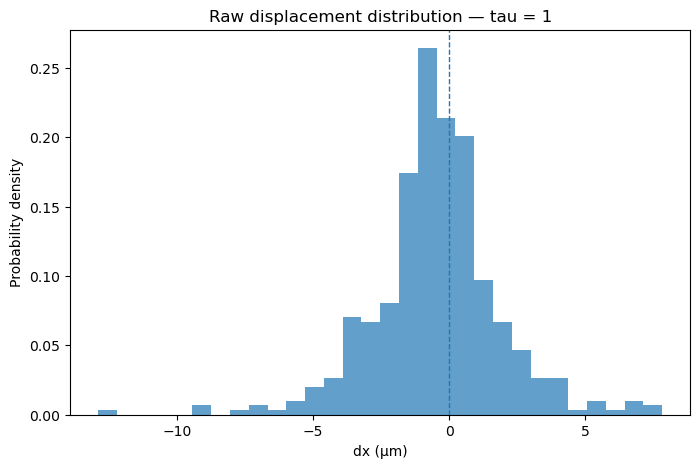

In [11]:
plt.figure(figsize=(8, 5))

plt.hist(
    tau1_raw_dx,
    bins=tau1_dx_bins,
    density=True,
    alpha=0.7,
)

plt.axvline(
    0,
    linestyle="--",
    linewidth=1,
)

plt.xlabel("dx (µm)")
plt.ylabel("Probability density")
plt.title(
    "Raw displacement distribution — tau = 1"
)

plt.show()

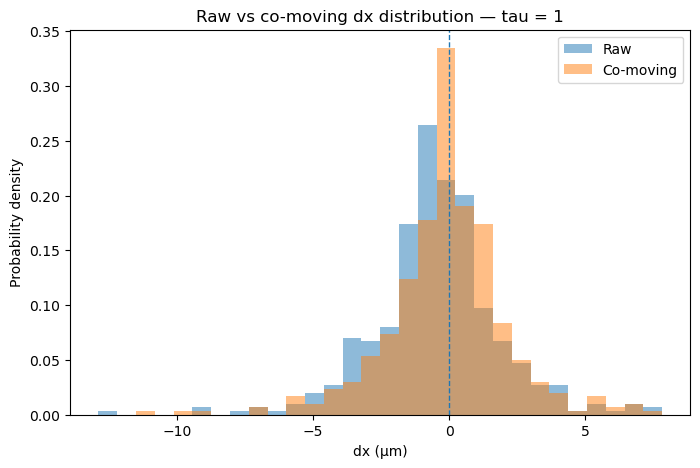

In [12]:
plt.figure(figsize=(8, 5))

plt.hist(
    tau1_raw_dx,
    bins=tau1_dx_bins,
    density=True,
    alpha=0.5,
    label="Raw",
)

plt.hist(
    tau1_comoving_dx,
    bins=tau1_dx_bins,
    density=True,
    alpha=0.5,
    label="Co-moving",
)

plt.axvline(
    0,
    linestyle="--",
    linewidth=1,
)

plt.xlabel("dx (µm)")
plt.ylabel("Probability density")
plt.title(
    "Raw vs co-moving dx distribution — tau = 1"
)

plt.legend()
plt.show()

In [13]:
def get_displacement_series(
    data: pd.DataFrame,
    representation: str,
    tau_frames: int,
    component: str,
) -> pd.Series:
    """
    Return one displacement component for a selected
    representation and temporal lag.
    """

    valid_components = {
        "dx": "dx_um",
        "dy": "dy_um",
    }

    if component not in valid_components:
        raise ValueError(
            "component must be either 'dx' or 'dy'"
        )

    column_name = valid_components[component]

    mask = (
        data["representation"].eq(representation)
        & data["tau_frames"].eq(tau_frames)
    )

    return (
        data.loc[mask, column_name]
        .copy()
    )

In [14]:
def make_shared_bins(
    first: pd.Series,
    second: pd.Series,
    n_bins: int = 30,
) -> np.ndarray:
    """
    Build common histogram bin edges from two samples.
    """

    combined = pd.concat(
        [first, second],
        ignore_index=True,
    )

    minimum = combined.min()
    maximum = combined.max()

    return np.linspace(
        minimum,
        maximum,
        n_bins + 1,
    )

In [15]:
def plot_raw_vs_comoving_histogram(
    data: pd.DataFrame,
    tau_frames: int,
    component: str,
    n_bins: int = 30,
) -> None:
    """
    Plot normalized raw and co-moving displacement
    histograms using shared bin edges.
    """

    raw_values = get_displacement_series(
        data=data,
        representation="raw",
        tau_frames=tau_frames,
        component=component,
    )

    comoving_values = get_displacement_series(
        data=data,
        representation="comoving",
        tau_frames=tau_frames,
        component=component,
    )

    bins = make_shared_bins(
        raw_values,
        comoving_values,
        n_bins=n_bins,
    )

    plt.figure(figsize=(8, 5))

    plt.hist(
        raw_values,
        bins=bins,
        density=True,
        alpha=0.5,
        label="Raw",
    )

    plt.hist(
        comoving_values,
        bins=bins,
        density=True,
        alpha=0.5,
        label="Co-moving",
    )

    plt.axvline(
        0,
        linestyle="--",
        linewidth=1,
    )

    plt.xlabel(
        f"{component} (µm)"
    )

    plt.ylabel(
        "Probability density"
    )

    plt.title(
        f"Raw vs co-moving {component} distribution "
        f"— tau = {tau_frames}"
    )

    plt.legend()
    plt.show()

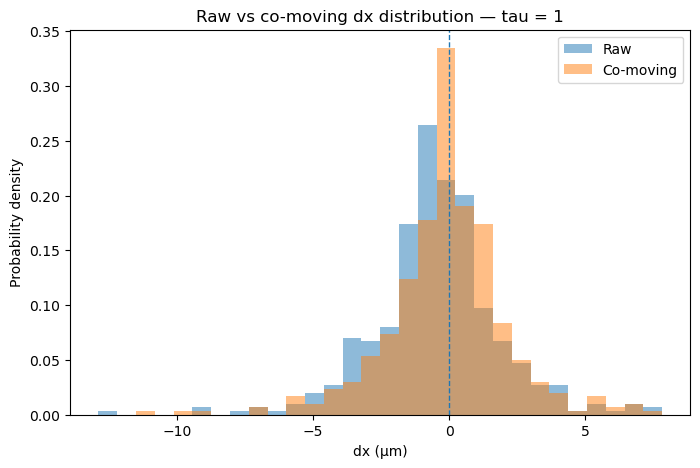

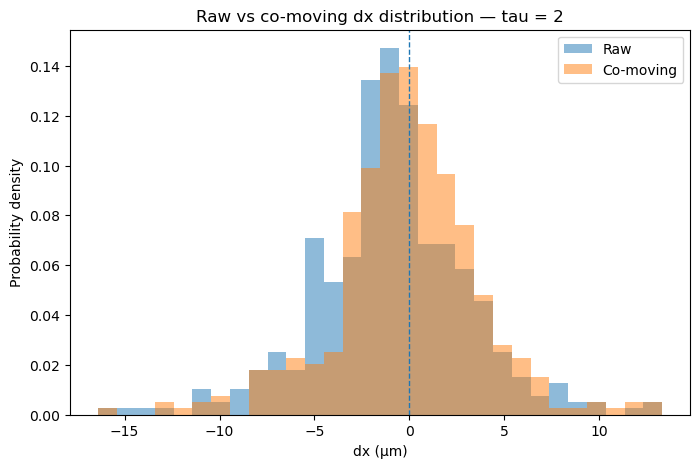

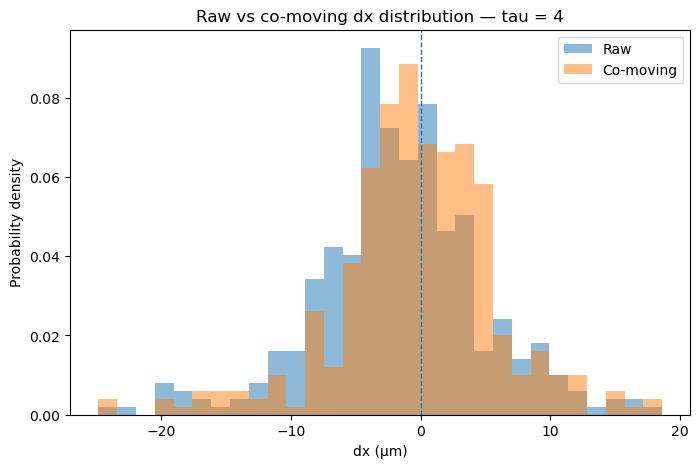

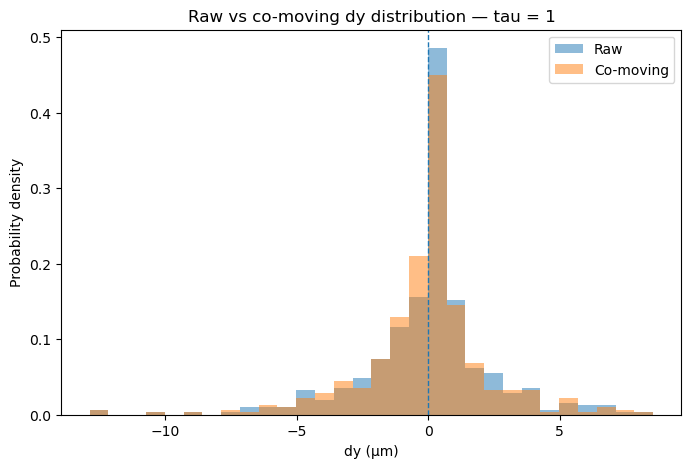

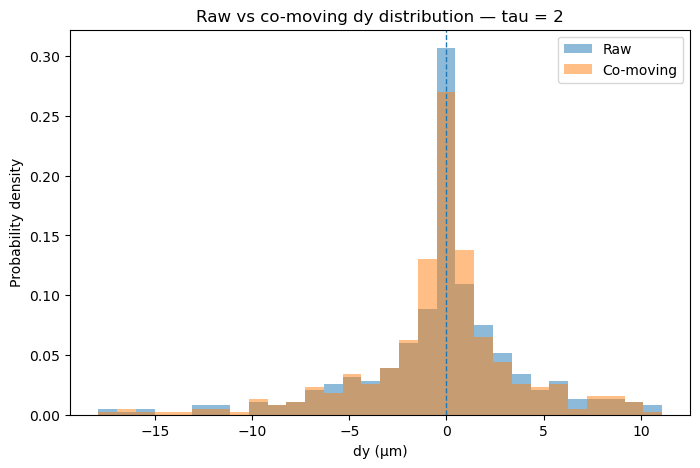

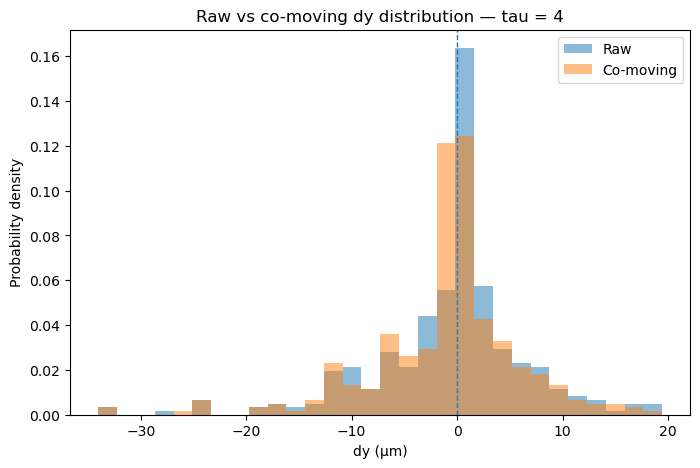

In [16]:
plot_raw_vs_comoving_histogram(
    steps_analysis,
    tau_frames=1,
    component="dx",
)

plot_raw_vs_comoving_histogram(
    steps_analysis,
    tau_frames=2,
    component="dx",
)

plot_raw_vs_comoving_histogram(
    steps_analysis,
    tau_frames=4,
    component="dx",
)


plot_raw_vs_comoving_histogram(
    steps_analysis,
    tau_frames=1,
    component="dy",
)

plot_raw_vs_comoving_histogram(
    steps_analysis,
    tau_frames=2,
    component="dy",
)

plot_raw_vs_comoving_histogram(
    steps_analysis,
    tau_frames=4,
    component="dy",
)

In [17]:
COMPONENT_COLUMNS = {
    "dx": "dx_um",
    "dy": "dy_um",
}

REPRESENTATIONS = [
    "raw",
    "comoving",
]

diagnostic_records = []

for representation in REPRESENTATIONS:
    for tau_frames in TAUS:
        for component, column_name in COMPONENT_COLUMNS.items():

            values = (
                steps_analysis
                .loc[
                    (
                        steps_analysis["representation"]
                        .eq(representation)
                    )
                    & (
                        steps_analysis["tau_frames"]
                        .eq(tau_frames)
                    ),
                    column_name,
                ]
                .dropna()
            )

            quantiles = values.quantile(
                [
                    0.01,
                    0.05,
                    0.25,
                    0.50,
                    0.75,
                    0.95,
                    0.99,
                ]
            )

            q25 = quantiles.loc[0.25]
            q75 = quantiles.loc[0.75]

            diagnostic_records.append(
                {
                    "representation": representation,
                    "tau_frames": tau_frames,
                    "component": component,
                    "n": len(values),
                    "minimum_um": values.min(),
                    "q01_um": quantiles.loc[0.01],
                    "q05_um": quantiles.loc[0.05],
                    "q25_um": q25,
                    "median_um": quantiles.loc[0.50],
                    "q75_um": q75,
                    "q95_um": quantiles.loc[0.95],
                    "q99_um": quantiles.loc[0.99],
                    "maximum_um": values.max(),
                    "iqr_um": q75 - q25,
                    "skewness": values.skew(),
                    "n_exact_zero": int(
                        values.eq(0).sum()
                    ),
                    "fraction_exact_zero": (
                        values.eq(0).mean()
                    ),
                }
            )

distribution_diagnostics = pd.DataFrame(
    diagnostic_records
)

display(distribution_diagnostics)

,representation,tau_frames,component,n,minimum_um,q01_um,q05_um,q25_um,median_um,q75_um,q95_um,q99_um,maximum_um,iqr_um,skewness,n_exact_zero,fraction_exact_zero
0,raw,1,dx,433,-12.882300,-6.892456,-4.149317,-1.500000,-0.483247,0.643010,3.319121,6.473270,7.800000,2.143010,-0.276562,17,0.039261
1,raw,1,dy,433,-12.863318,-7.222032,-4.521743,-0.911674,0.000000,0.878019,3.800610,6.657450,8.400432,1.789693,-0.695198,87,0.200924
2,raw,2,dx,398,-15.720989,-11.415036,-7.511662,-2.704969,-1.043047,1.364652,5.903430,9.658889,13.327839,4.069621,-0.057915,7,0.017588
3,raw,2,dy,398,-17.906126,-15.225155,-7.612310,-1.568195,0.000000,1.524942,6.885254,9.872045,11.092792,3.093137,-0.776114,74,0.185930
4,raw,4,dx,343,-24.842169,-19.508499,-12.097288,-5.074159,-1.747158,1.990111,9.219102,14.691145,17.578750,7.064270,-0.170571,7,0.020408
5,raw,4,dy,343,-34.010622,-25.057022,-12.596344,-3.265280,0.000000,2.423667,10.062096,17.032870,19.435225,5.688947,-0.921008,57,0.166181
6,comoving,1,dx,433,-11.351988,-6.583742,-3.764469,-0.955075,0.000000,1.028638,3.333873,6.203390,7.826134,1.983713,-0.448663,25,0.057737
7,comoving,1,dy,433,-12.863318,-7.290633,-4.194217,-0.877851,0.000000,0.710356,3.732904,6.792602,8.546218,1.588207,-0.715610,57,0.131640
8,comoving,2,dx,398,-16.382257,-11.338189,-6.701895,-1.974404,-0.142888,1.902348,5.823999,10.391800,13.185339,3.876752,-0.241738,0,0.000000
9,comoving,2,dy,398,-17.906126,-14.906090,-7.934550,-1.578343,0.000000,1.238330,6.154275,9.267457,10.414073,2.816673,-0.844182,11,0.027638


In [18]:
display(
    distribution_diagnostics[
        [
            "representation",
            "tau_frames",
            "component",
            "n",
            "q05_um",
            "median_um",
            "q95_um",
            "iqr_um",
            "skewness",
            "fraction_exact_zero",
        ]
    ]
)

,representation,tau_frames,component,n,q05_um,median_um,q95_um,iqr_um,skewness,fraction_exact_zero
0,raw,1,dx,433,-4.149317,-0.483247,3.319121,2.143010,-0.276562,0.039261
1,raw,1,dy,433,-4.521743,0.000000,3.800610,1.789693,-0.695198,0.200924
2,raw,2,dx,398,-7.511662,-1.043047,5.903430,4.069621,-0.057915,0.017588
3,raw,2,dy,398,-7.612310,0.000000,6.885254,3.093137,-0.776114,0.185930
4,raw,4,dx,343,-12.097288,-1.747158,9.219102,7.064270,-0.170571,0.020408
5,raw,4,dy,343,-12.596344,0.000000,10.062096,5.688947,-0.921008,0.166181
6,comoving,1,dx,433,-3.764469,0.000000,3.333873,1.983713,-0.448663,0.057737
7,comoving,1,dy,433,-4.194217,0.000000,3.732904,1.588207,-0.715610,0.131640
8,comoving,2,dx,398,-6.701895,-0.142888,5.823999,3.876752,-0.241738,0.000000
9,comoving,2,dy,398,-7.934550,0.000000,6.154275,2.816673,-0.844182,0.027638


In [19]:
def show_extreme_steps(
    data: pd.DataFrame,
    representation: str,
    tau_frames: int,
    component: str,
    n: int = 5,
) -> pd.DataFrame:

    column_name = COMPONENT_COLUMNS[component]

    selected = (
        data
        .loc[
            (
                data["representation"]
                .eq(representation)
            )
            & (
                data["tau_frames"]
                .eq(tau_frames)
            )
        ]
        .copy()
    )

    selected["absolute_displacement"] = (
        selected[column_name].abs()
    )

    return (
        selected
        .nlargest(
            n,
            "absolute_displacement",
        )
        [
            [
                "representation",
                "cell_id",
                "tau_frames",
                "frame_start",
                "frame_end",
                column_name,
                "absolute_displacement",
            ]
        ]
    )


display(
    show_extreme_steps(
        steps_analysis,
        representation="raw",
        tau_frames=4,
        component="dy",
        n=10,
    )
)

,representation,cell_id,tau_frames,frame_start,frame_end,dy_um,absolute_displacement
1006,raw,10,4,21,25,-34.010622,34.010622
1005,raw,10,4,20,24,-33.174825,33.174825
1004,raw,10,4,19,23,-27.284092,27.284092
1003,raw,10,4,18,22,-25.068236,25.068236
1007,raw,10,4,22,26,-25.041537,25.041537
1008,raw,10,4,23,27,-24.318862,24.318862
993,raw,7,4,39,43,-23.793071,23.793071
1028,raw,10,4,43,47,19.435225,19.435225
1083,raw,16,4,4,8,19.020894,19.020894
992,raw,7,4,38,42,-18.261717,18.261717


In [20]:
cell10_track = (
    raw_tracks
    .loc[
        raw_tracks["cell_id"].eq(10)
    ]
    .sort_values("frame")
    .copy()
)

display(cell10_track)

,cell_id,frame,t_min,x_um,y_um
206,10,13,260.0,74.641595,249.145439
207,10,14,280.0,76.857963,242.516977
208,10,15,300.0,78.663491,237.644884
209,10,16,320.0,80.272102,236.653568
210,10,17,340.0,80.583789,236.547575
211,10,18,360.0,80.522355,237.393920
212,10,19,380.0,81.893572,234.896019
213,10,20,400.0,83.312589,230.231810
214,10,21,420.0,84.004119,224.863631
215,10,22,440.0,84.940349,212.325683


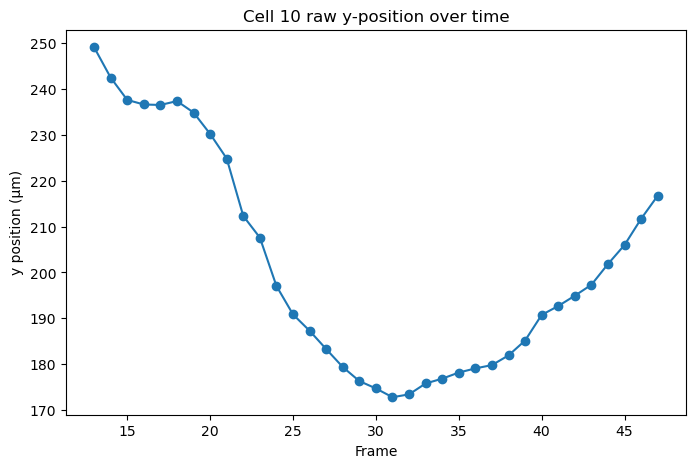

In [21]:
plt.figure(figsize=(8, 5))

plt.plot(
    cell10_track["frame"],
    cell10_track["y_um"],
    marker="o",
)

plt.xlabel("Frame")
plt.ylabel("y position (µm)")
plt.title("Cell 10 raw y-position over time")

plt.show()

In [22]:
cell10_tau1 = (
    steps_raw
    .loc[
        (
            steps_raw["cell_id"].eq(10)
            & steps_raw["tau_frames"].eq(1)
        )
    ]
    .sort_values("frame_start")
    .copy()
)

cell10_tau1["step_magnitude_um"] = np.hypot(
    cell10_tau1["dx_um"],
    cell10_tau1["dy_um"],
)

display(
    cell10_tau1[
        [
            "frame_start",
            "frame_end",
            "dx_um",
            "dy_um",
            "step_magnitude_um",
        ]
    ]
)

,frame_start,frame_end,dx_um,dy_um,step_magnitude_um
195,13,14,2.216367,-6.628463,6.989192
196,14,15,1.805528,-4.872093,5.195885
197,15,16,1.608612,-0.991316,1.889534
198,16,17,0.311687,-0.105993,0.329216
199,17,18,-0.061435,0.846345,0.848572
200,18,19,1.371217,-2.497901,2.849516
201,19,20,1.419017,-4.664209,4.875290
202,20,21,0.691530,-5.368179,5.412537
203,21,22,0.936230,-12.537948,12.572854
204,22,23,0.751102,-4.713757,4.773223


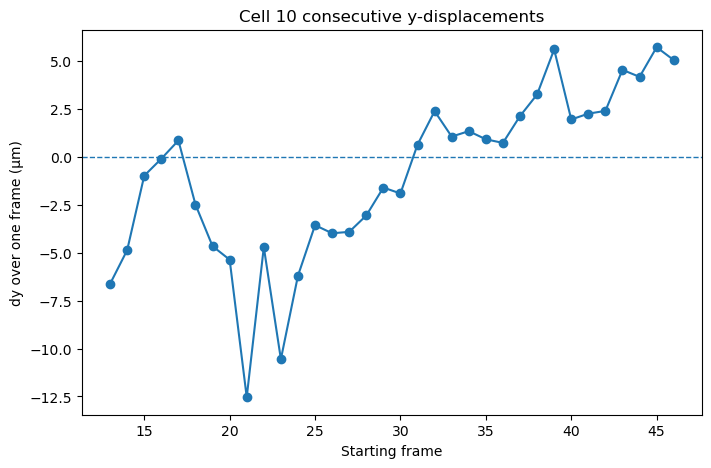

In [23]:
plt.figure(figsize=(8, 5))

plt.plot(
    cell10_tau1["frame_start"],
    cell10_tau1["dy_um"],
    marker="o",
)

plt.axhline(
    0,
    linestyle="--",
    linewidth=1,
)

plt.xlabel("Starting frame")
plt.ylabel("dy over one frame (µm)")
plt.title("Cell 10 consecutive y-displacements")

plt.show()

In [24]:
raw_tau1 = (
    steps_analysis
    .loc[
        (
            steps_analysis["representation"].eq("raw")
            & steps_analysis["tau_frames"].eq(1)
        )
    ]
    .copy()
)

zero_dy_by_cell = (
    raw_tau1
    .groupby("cell_id")
    .agg(
        n_steps=("dy_um", "size"),
        n_zero_dy=(
            "dy_um",
            lambda values: values.eq(0).sum(),
        ),
    )
    .reset_index()
)

zero_dy_by_cell["fraction_zero_dy"] = (
    zero_dy_by_cell["n_zero_dy"]
    / zero_dy_by_cell["n_steps"]
)

zero_dy_by_cell = (
    zero_dy_by_cell
    .sort_values(
        "fraction_zero_dy",
        ascending=False,
    )
)

display(zero_dy_by_cell)

,cell_id,n_steps,n_zero_dy,fraction_zero_dy
2,2,6,6,1.000000
12,12,19,19,1.000000
14,14,3,3,1.000000
30,30,3,3,1.000000
31,31,2,2,1.000000
26,26,10,10,1.000000
21,21,26,26,1.000000
13,13,6,5,0.833333
11,11,8,6,0.750000
28,28,6,4,0.666667


In [25]:
n_zero_dx = int(
    raw_tau1["dx_um"].eq(0).sum()
)

n_zero_dy = int(
    raw_tau1["dy_um"].eq(0).sum()
)

n_zero_both = int(
    (
        raw_tau1["dx_um"].eq(0)
        & raw_tau1["dy_um"].eq(0)
    ).sum()
)

print("Exact zero dx:", n_zero_dx)
print("Exact zero dy:", n_zero_dy)
print("Exact zero in both dx and dy:", n_zero_both)

Exact zero dx: 17
Exact zero dy: 87
Exact zero in both dx and dy: 13


In [26]:
tau1_magnitudes = (
    steps_raw
    .loc[
        steps_raw["tau_frames"].eq(1)
    ]
    .copy()
)

tau1_magnitudes["step_magnitude_um"] = np.hypot(
    tau1_magnitudes["dx_um"],
    tau1_magnitudes["dy_um"],
)

print(
    "Maximum tau=1 step magnitude:",
    tau1_magnitudes["step_magnitude_um"].max(),
)

print(
    "Number of tau=1 steps > 8 µm:",
    int(
        (
            tau1_magnitudes["step_magnitude_um"] > 8
        ).sum()
    ),
)

display(
    tau1_magnitudes
    .nlargest(
        10,
        "step_magnitude_um",
    )
    [
        [
            "cell_id",
            "frame_start",
            "frame_end",
            "dx_um",
            "dy_um",
            "step_magnitude_um",
        ]
    ]
)

Maximum tau=1 step magnitude: 12.981616993182563
Number of tau=1 steps > 8 µm: 9


,cell_id,frame_start,frame_end,dx_um,dy_um,step_magnitude_um
140,6,34,35,-12.882300,-1.602724,12.981617
399,27,36,37,0.337124,-12.863318,12.867735
203,10,21,22,0.936230,-12.537948,12.572854
205,10,23,24,3.559747,-10.554941,11.139057
314,18,25,26,6.988468,8.400432,10.927303
35,3,8,9,5.444924,7.818417,9.527583
307,17,5,6,-8.844565,3.127350,9.381186
344,21,24,25,-9.300000,0.000000,9.300000
413,28,40,41,0.000000,-8.700000,8.700000
183,7,40,41,-2.901281,-7.297779,7.853344


In [27]:
cell21_track = (
    raw_tracks
    .loc[
        raw_tracks["cell_id"].eq(21)
    ]
    .sort_values("frame")
    .copy()
)

display(
    cell21_track[
        [
            "cell_id",
            "frame",
            "x_um",
            "y_um",
        ]
    ]
)

print(
    "Unique x positions:",
    cell21_track["x_um"].nunique(),
)

print(
    "Unique y positions:",
    cell21_track["y_um"].nunique(),
)

print(
    "y values:",
    cell21_track["y_um"].unique(),
)

,cell_id,frame,x_um,y_um
366,21,21,280.800011,0.0
367,21,22,277.200011,0.0
368,21,23,271.200011,0.0
369,21,24,270.300011,0.0
370,21,25,261.000010,0.0
371,21,26,257.700010,0.0
372,21,27,255.900010,0.0
373,21,28,252.600010,0.0
374,21,29,248.700010,0.0
375,21,30,247.500010,0.0


Unique x positions: 26
Unique y positions: 1
y values: [0.]


In [28]:
all_zero_dy_cells = (
    zero_dy_by_cell
    .loc[
        zero_dy_by_cell["fraction_zero_dy"].eq(1),
        "cell_id",
    ]
    .tolist()
)

print(
    "Cells with 100% zero tau=1 dy:",
    all_zero_dy_cells,
)

flat_y_summary = []

for cell_id in all_zero_dy_cells:

    cell_track = (
        raw_tracks
        .loc[
            raw_tracks["cell_id"].eq(cell_id)
        ]
    )

    flat_y_summary.append(
        {
            "cell_id": cell_id,
            "n_positions": len(cell_track),
            "n_unique_x": cell_track["x_um"].nunique(),
            "n_unique_y": cell_track["y_um"].nunique(),
            "x_range_um": (
                cell_track["x_um"].max()
                - cell_track["x_um"].min()
            ),
            "y_range_um": (
                cell_track["y_um"].max()
                - cell_track["y_um"].min()
            ),
        }
    )

flat_y_summary = pd.DataFrame(
    flat_y_summary
)

display(flat_y_summary)

Cells with 100% zero tau=1 dy: [2, 12, 14, 30, 31, 26, 21]


,cell_id,n_positions,n_unique_x,n_unique_y,x_range_um,y_range_um
0,2,8,6,1,3.000000,0.0
1,12,20,16,1,9.000000,0.0
2,14,4,4,1,12.600000,0.0
3,30,4,4,1,15.300001,0.0
4,31,3,1,1,0.000000,0.0
5,26,11,8,1,2.100000,0.0
6,21,27,26,1,49.200002,0.0


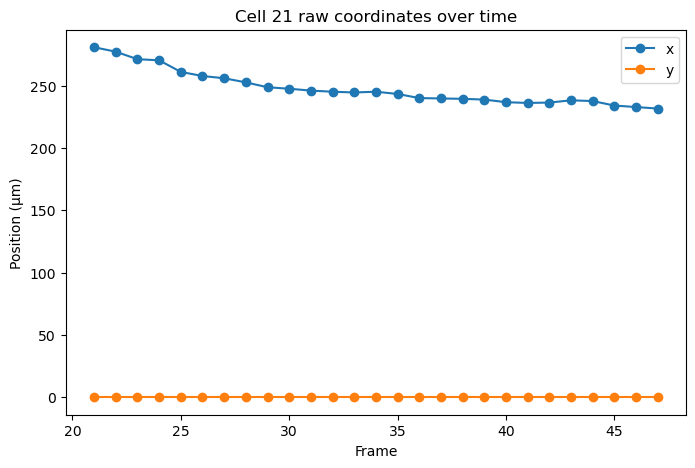

In [29]:
plt.figure(figsize=(8, 5))

plt.plot(
    cell21_track["frame"],
    cell21_track["x_um"],
    marker="o",
    label="x",
)

plt.plot(
    cell21_track["frame"],
    cell21_track["y_um"],
    marker="o",
    label="y",
)

plt.xlabel("Frame")
plt.ylabel("Position (µm)")
plt.title("Cell 21 raw coordinates over time")

plt.legend()
plt.show()

## Data-quality note before density estimation

Exploratory diagnostics identified two features that should be kept in mind
during interpretation:

1. Several large multi-frame displacements arise from sustained motion within
   individual trajectories and from overlapping lag windows. These observations
   are retained because no clear evidence of tracking failure was identified.

2. Seven tracks show constant raw y coordinates and account for a substantial
   fraction of exact-zero dy values. Their origin was not resolved further
   because this is an exploratory training project rather than a
   publication-grade tracking-validation study.

The primary Phase 5 analysis therefore retains all validated tracks.

A simple sensitivity analysis excluding the constant-y tracks will be performed
later to determine whether the main asymmetry conclusions depend strongly on
this subset.

These limitations affect the strength of biological interpretation, but they do
not prevent the planned exploratory probability-density analysis.

In [30]:
def freedman_diaconis_bin_width(
    values: pd.Series,
) -> float:
    """
    Calculate the Freedman-Diaconis histogram
    bin width for a one-dimensional sample.
    """

    clean_values = values.dropna()

    n = len(clean_values)

    if n < 2:
        raise ValueError(
            "At least two observations are required."
        )

    q25 = clean_values.quantile(0.25)
    q75 = clean_values.quantile(0.75)

    iqr = q75 - q25

    if iqr == 0:
        raise ValueError(
            "IQR is zero; Freedman-Diaconis "
            "bin width is undefined."
        )

    bin_width = (
        2
        * iqr
        / np.cbrt(n)
    )

    return float(bin_width)

In [31]:
def make_fd_bins(
    first: pd.Series,
    second: pd.Series,
) -> np.ndarray:
    """
    Build shared Freedman-Diaconis bin edges
    for two samples.
    """

    combined = pd.concat(
        [first, second],
        ignore_index=True,
    ).dropna()

    bin_width = (
        freedman_diaconis_bin_width(
            combined
        )
    )

    minimum = combined.min()
    maximum = combined.max()

    data_range = maximum - minimum

    n_bins = int(
        np.ceil(
            data_range / bin_width
        )
    )

    n_bins = max(n_bins, 1)

    return np.linspace(
        minimum,
        maximum,
        n_bins + 1,
    )

In [32]:
fd_records = []

for representation in REPRESENTATIONS:
    for tau_frames in TAUS:
        for component in ["dx", "dy"]:

            values = get_displacement_series(
                data=steps_analysis,
                representation=representation,
                tau_frames=tau_frames,
                component=component,
            )

            bin_width = (
                freedman_diaconis_bin_width(
                    values
                )
            )

            value_range = (
                values.max()
                - values.min()
            )

            n_bins = int(
                np.ceil(
                    value_range
                    / bin_width
                )
            )

            fd_records.append(
                {
                    "representation": representation,
                    "tau_frames": tau_frames,
                    "component": component,
                    "bin_width_um": bin_width,
                    "n_bins": n_bins,
                }
            )

fd_summary = pd.DataFrame(
    fd_records
)

display(fd_summary)

,representation,tau_frames,component,bin_width_um,n_bins
0,raw,1,dx,0.566533,37
1,raw,1,dy,0.473129,45
2,raw,2,dx,1.106512,27
3,raw,2,dy,0.841010,35
4,raw,4,dx,2.018363,22
5,raw,4,dy,1.625413,33
6,comoving,1,dx,0.524420,37
7,comoving,1,dy,0.419863,51
8,comoving,2,dx,1.054072,29
9,comoving,2,dy,0.765841,37


In [33]:
def plot_fd_histogram_comparison(
    data: pd.DataFrame,
    tau_frames: int,
    component: str,
) -> None:
    """
    Compare raw and co-moving displacement
    histograms using shared Freedman-Diaconis bins.
    """

    raw_values = get_displacement_series(
        data=data,
        representation="raw",
        tau_frames=tau_frames,
        component=component,
    )

    comoving_values = get_displacement_series(
        data=data,
        representation="comoving",
        tau_frames=tau_frames,
        component=component,
    )

    bins = make_fd_bins(
        raw_values,
        comoving_values,
    )

    plt.figure(figsize=(8, 5))

    plt.hist(
        raw_values,
        bins=bins,
        density=True,
        alpha=0.5,
        label="Raw",
    )

    plt.hist(
        comoving_values,
        bins=bins,
        density=True,
        alpha=0.5,
        label="Co-moving",
    )

    plt.axvline(
        0,
        linestyle="--",
        linewidth=1,
    )

    plt.xlabel(
        f"{component} (µm)"
    )

    plt.ylabel(
        "Probability density"
    )

    plt.title(
        f"FD histogram: raw vs co-moving "
        f"{component} — tau = {tau_frames}"
    )

    plt.legend()

    plt.show()

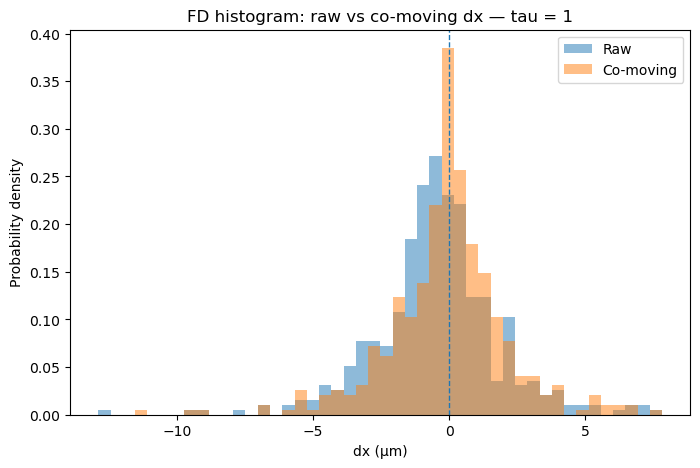

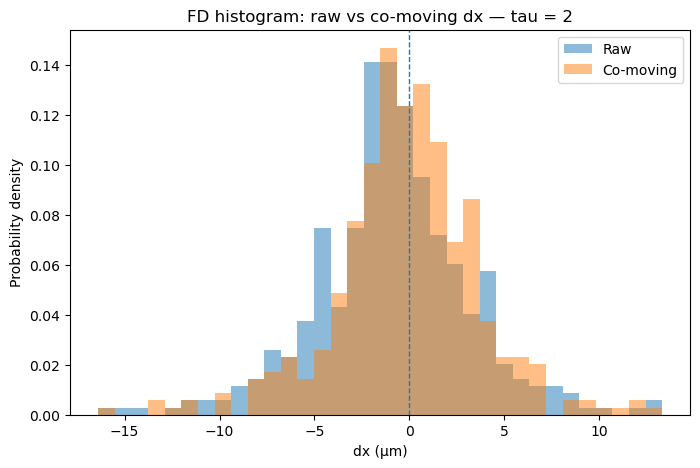

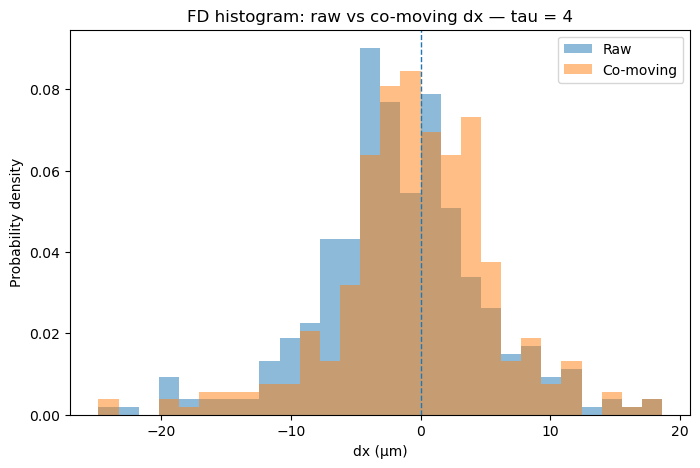

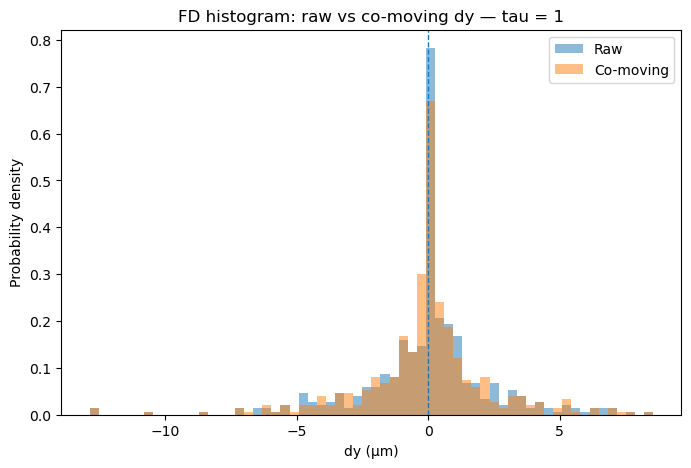

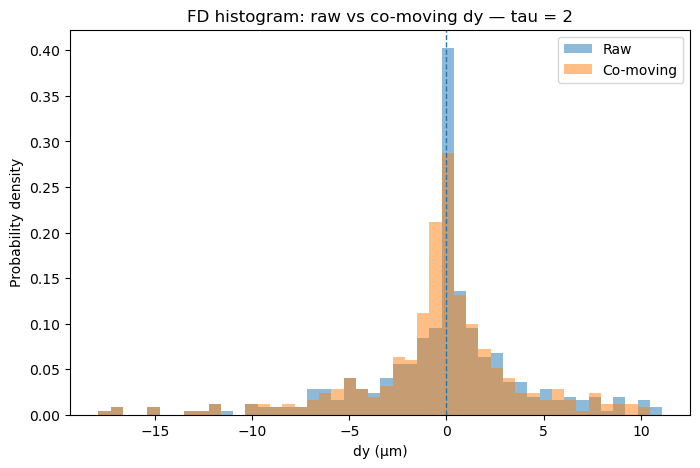

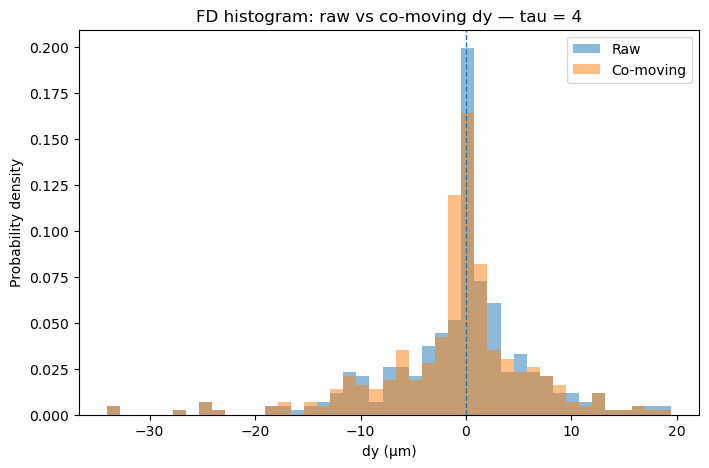

In [34]:
for tau_frames in TAUS:
    plot_fd_histogram_comparison(
        steps_analysis,
        tau_frames=tau_frames,
        component="dx",
    )

for tau_frames in TAUS:
    plot_fd_histogram_comparison(
        steps_analysis,
        tau_frames=tau_frames,
        component="dy",
    )

In [35]:
from sklearn.neighbors import KernelDensity

In [36]:
def silverman_bandwidth(
    values: pd.Series,
) -> float:
    """
    Estimate a robust one-dimensional KDE bandwidth.
    """

    clean_values = (
        values
        .dropna()
        .to_numpy()
    )

    n = len(clean_values)

    std = np.std(
        clean_values,
        ddof=1,
    )

    q25, q75 = np.quantile(
        clean_values,
        [0.25, 0.75],
    )

    iqr = q75 - q25

    robust_scale = min(
        std,
        iqr / 1.34,
    )

    bandwidth = (
        0.9
        * robust_scale
        * n ** (-1 / 5)
    )

    return float(bandwidth)

In [37]:
def evaluate_kde_1d(
    values: pd.Series,
    grid: np.ndarray,
    bandwidth: float,
) -> np.ndarray:
    """
    Fit a one-dimensional Gaussian KDE and
    evaluate its density on a supplied grid.
    """

    sample = (
        values
        .dropna()
        .to_numpy()
        .reshape(-1, 1)
    )

    grid_2d = grid.reshape(-1, 1)

    kde = KernelDensity(
        kernel="gaussian",
        bandwidth=bandwidth,
    )

    kde.fit(sample)

    log_density = kde.score_samples(
        grid_2d
    )

    density = np.exp(
        log_density
    )

    return density

In [38]:
def plot_kde_comparison(
    data: pd.DataFrame,
    tau_frames: int,
    component: str,
) -> None:

    raw_values = get_displacement_series(
        data,
        "raw",
        tau_frames,
        component,
    )

    comoving_values = get_displacement_series(
        data,
        "comoving",
        tau_frames,
        component,
    )

    combined = pd.concat(
        [
            raw_values,
            comoving_values,
        ],
        ignore_index=True,
    )

    grid = np.linspace(
        combined.min(),
        combined.max(),
        500,
    )

    raw_bandwidth = silverman_bandwidth(
        raw_values
    )

    comoving_bandwidth = (
        silverman_bandwidth(
            comoving_values
        )
    )

    raw_density = evaluate_kde_1d(
        raw_values,
        grid,
        raw_bandwidth,
    )

    comoving_density = evaluate_kde_1d(
        comoving_values,
        grid,
        comoving_bandwidth,
    )

    plt.figure(figsize=(8, 5))

    plt.plot(
        grid,
        raw_density,
        label="Raw",
    )

    plt.plot(
        grid,
        comoving_density,
        label="Co-moving",
    )

    plt.axvline(
        0,
        linestyle="--",
        linewidth=1,
    )

    plt.xlabel(
        f"{component} (µm)"
    )

    plt.ylabel(
        "Estimated probability density"
    )

    plt.title(
        f"KDE: raw vs co-moving "
        f"{component} — tau = {tau_frames}"
    )

    plt.legend()
    plt.show()

    print(
        "Raw bandwidth:",
        raw_bandwidth,
    )

    print(
        "Co-moving bandwidth:",
        comoving_bandwidth,
    )

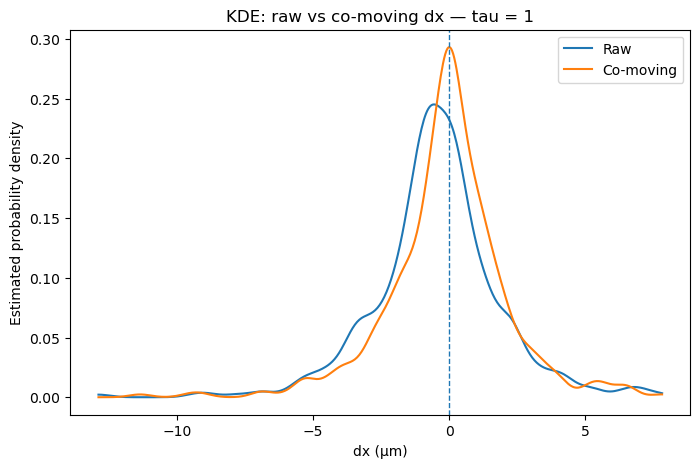

Raw bandwidth: 0.4274292795049361
Co-moving bandwidth: 0.39565704879867414


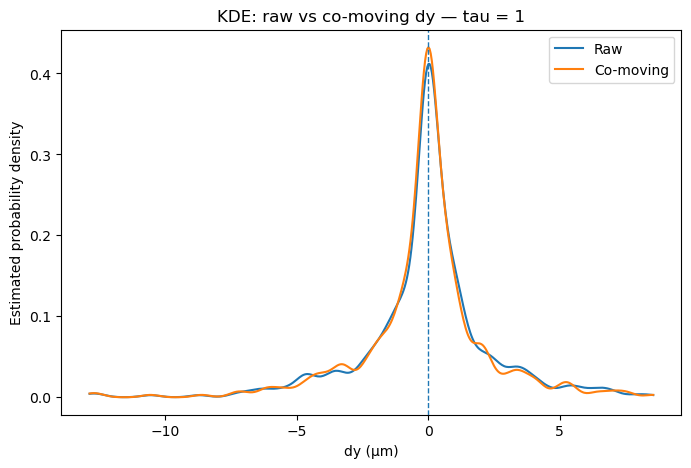

Raw bandwidth: 0.3569593674752061
Co-moving bandwidth: 0.3167722590778661


In [39]:
plot_kde_comparison(
    steps_analysis,
    tau_frames=1,
    component="dx",
)

plot_kde_comparison(
    steps_analysis,
    tau_frames=1,
    component="dy",
)

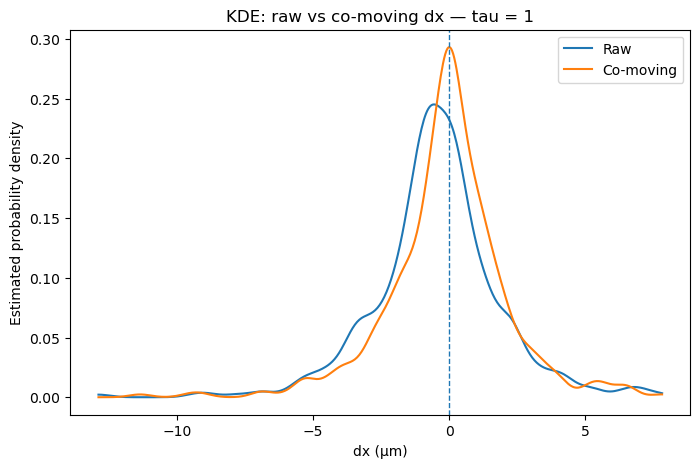

Raw bandwidth: 0.4274292795049361
Co-moving bandwidth: 0.39565704879867414


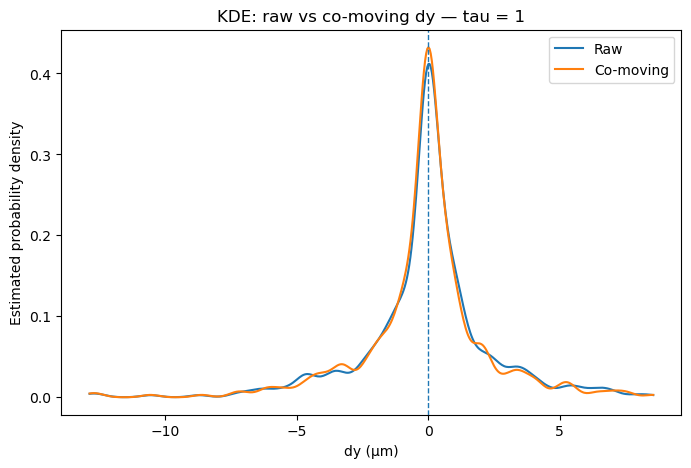

Raw bandwidth: 0.3569593674752061
Co-moving bandwidth: 0.3167722590778661


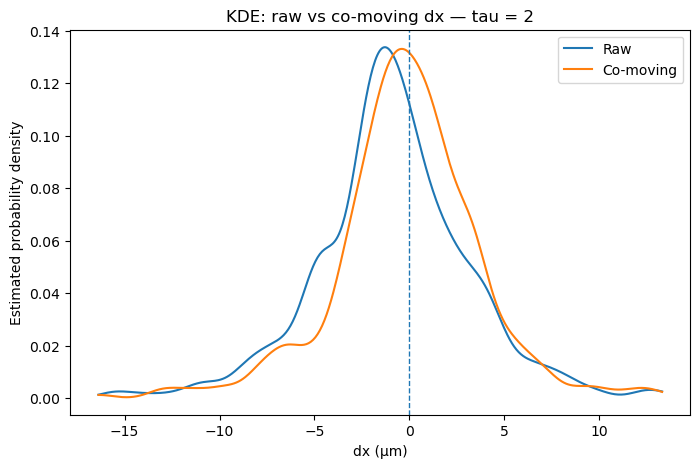

Raw bandwidth: 0.825496110786699
Co-moving bandwidth: 0.7863739682536905


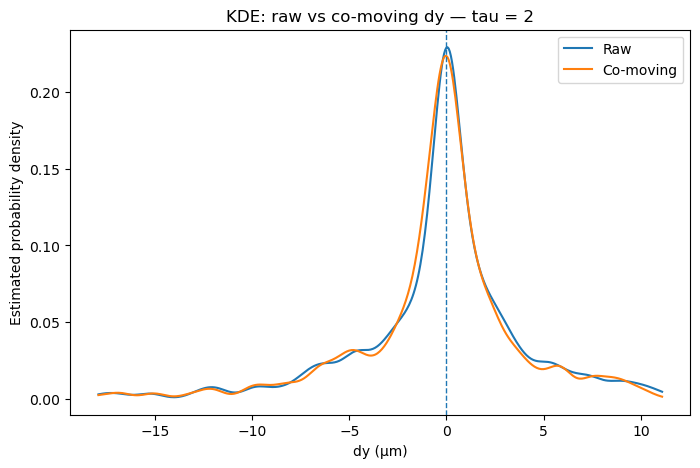

Raw bandwidth: 0.6274226602014993
Co-moving bandwidth: 0.5713437594847264


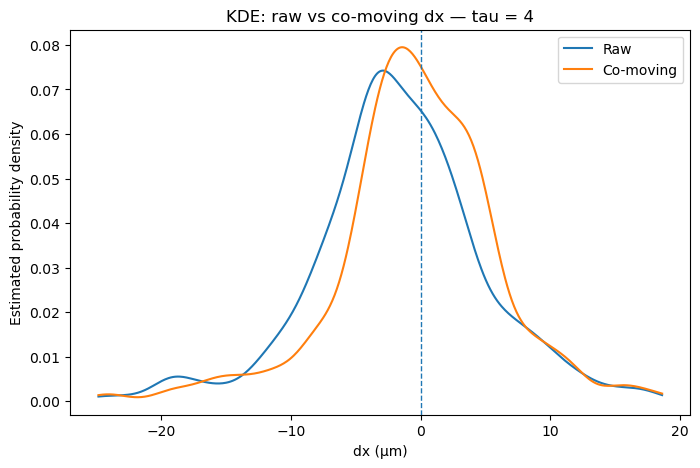

Raw bandwidth: 1.4762032428161473
Co-moving bandwidth: 1.4375981830832534


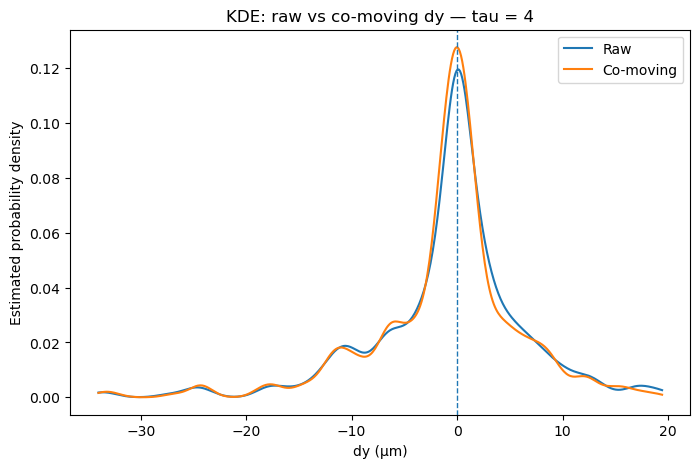

Raw bandwidth: 1.1888053752929848
Co-moving bandwidth: 1.0547334805150923


In [40]:
for tau_frames in TAUS:
    for component in ["dx", "dy"]:

        plot_kde_comparison(
            steps_analysis,
            tau_frames=tau_frames,
            component=component,
        )

## Joint two-dimensional displacement density

The one-dimensional distributions of `dx` and `dy` are useful diagnostic
projections, but a cell displacement is fundamentally a two-dimensional
vector.

$$
\Delta \mathbf{r}
=
(\Delta x,\Delta y)
$$

The next step therefore estimates the joint probability density

$$
p(\Delta x,\Delta y)
$$

rather than considering the two coordinate distributions separately.

For spatial inversion, a displacement vector is mapped to

$$
-\Delta \mathbf{r}
=
(-\Delta x,-\Delta y)
$$

Therefore, the exploratory asymmetry analysis compares

$$
p(\Delta \mathbf{r})
$$

with

$$
p(-\Delta \mathbf{r})
$$

or equivalently,

$$
p(\Delta x,\Delta y)
$$

with

$$
p(-\Delta x,-\Delta y)
$$

This analysis measures **single-displacement spatial inversion asymmetry**.

It should not yet be interpreted as definitive trajectory-level time
irreversibility or thermodynamic entropy production.

In [42]:
def get_displacement_points(
    data: pd.DataFrame,
    representation: str,
    tau_frames: int,
) -> np.ndarray:
    """
    Return two-dimensional displacement vectors
    [dx, dy] for one representation and lag.
    """

    mask = (
        data["representation"].eq(representation)
        & data["tau_frames"].eq(tau_frames)
    )

    points = (
        data
        .loc[
            mask,
            ["dx_um", "dy_um"],
        ]
        .dropna()
        .to_numpy()
    )

    return points

raw_tau1_points = get_displacement_points(
    steps_analysis,
    representation="raw",
    tau_frames=1,
)

print(raw_tau1_points.shape)
print(raw_tau1_points[:5])

(433, 2)
[[-5.09125217e+00  3.17279647e+00]
 [-3.72019571e+00  2.15500559e+00]
 [ 1.39304765e+00  5.34447651e-01]
 [ 9.19361942e-01  4.73663721e-03]
 [-1.04384853e+00  1.10839391e-02]]


In [43]:
def robust_scale_1d(
    values: np.ndarray,
) -> float:
    """
    Estimate a robust characteristic scale
    for one coordinate.
    """

    values = np.asarray(
        values,
        dtype=float,
    )

    std = np.std(
        values,
        ddof=1,
    )

    q25, q75 = np.quantile(
        values,
        [0.25, 0.75],
    )

    iqr_scale = (
        (q75 - q25)
        / 1.34
    )

    valid_scales = [
        scale
        for scale in [std, iqr_scale]
        if np.isfinite(scale)
        and scale > 0
    ]

    if not valid_scales:
        raise ValueError(
            "Could not estimate a positive scale."
        )

    return min(valid_scales)

In [44]:
def shared_bandwidth_2d(
    raw_points: np.ndarray,
    comoving_points: np.ndarray,
) -> float:
    """
    Estimate one shared isotropic KDE bandwidth
    for raw and co-moving displacement data.
    """

    combined = np.vstack(
        [
            raw_points,
            comoving_points,
        ]
    )

    scale_x = robust_scale_1d(
        combined[:, 0]
    )

    scale_y = robust_scale_1d(
        combined[:, 1]
    )

    characteristic_scale = np.sqrt(
        scale_x * scale_y
    )

    n = min(
        len(raw_points),
        len(comoving_points),
    )

    bandwidth = (
        characteristic_scale
        * n ** (-1 / 6)
    )

    return float(bandwidth)

In [45]:
def make_symmetric_2d_grid(
    raw_points: np.ndarray,
    comoving_points: np.ndarray,
    bandwidth: float,
    n_grid: int = 101,
):
    """
    Construct a symmetric 2D evaluation grid
    around the displacement origin.
    """

    combined = np.vstack(
        [
            raw_points,
            comoving_points,
        ]
    )

    x_limit = (
        np.max(
            np.abs(
                combined[:, 0]
            )
        )
        + 3 * bandwidth
    )

    y_limit = (
        np.max(
            np.abs(
                combined[:, 1]
            )
        )
        + 3 * bandwidth
    )

    x_grid = np.linspace(
        -x_limit,
        x_limit,
        n_grid,
    )

    y_grid = np.linspace(
        -y_limit,
        y_limit,
        n_grid,
    )

    return x_grid, y_grid

In [46]:
def evaluate_kde_2d(
    points: np.ndarray,
    x_grid: np.ndarray,
    y_grid: np.ndarray,
    bandwidth: float,
):
    """
    Fit and evaluate a two-dimensional Gaussian KDE.
    """

    xx, yy = np.meshgrid(
        x_grid,
        y_grid,
    )

    evaluation_points = np.column_stack(
        [
            xx.ravel(),
            yy.ravel(),
        ]
    )

    kde = KernelDensity(
        kernel="gaussian",
        bandwidth=bandwidth,
    )

    kde.fit(points)

    log_density = kde.score_samples(
        evaluation_points
    )

    density = (
        np.exp(log_density)
        .reshape(xx.shape)
    )

    return xx, yy, density

In [47]:
def inversion_asymmetry_index(
    density: np.ndarray,
    x_grid: np.ndarray,
    y_grid: np.ndarray,
):
    """
    Compare a normalized 2D density with its
    inversion-reflected counterpart.
    """

    dx_grid = (
        x_grid[1]
        - x_grid[0]
    )

    dy_grid = (
        y_grid[1]
        - y_grid[0]
    )

    cell_area = (
        dx_grid
        * dy_grid
    )

    grid_mass = (
        density.sum()
        * cell_area
    )

    p = (
        density
        / grid_mass
    )

    p_reversed = (
        p[::-1, ::-1]
    )

    epsilon = (
        p.max()
        * 1e-12
    )

    p_safe = (
        p + epsilon
    )

    reversed_safe = (
        p_reversed + epsilon
    )

    p_safe = (
        p_safe
        / (
            p_safe.sum()
            * cell_area
        )
    )

    reversed_safe = (
        reversed_safe
        / (
            reversed_safe.sum()
            * cell_area
        )
    )

    log_ratio = np.log(
        p_safe
        / reversed_safe
    )

    asymmetry = (
        (
            p_safe
            * log_ratio
        ).sum()
        * cell_area
    )

    return float(asymmetry), float(grid_mass)

In [48]:
asymmetry_records = []

for tau_frames in TAUS:

    raw_points = get_displacement_points(
        steps_analysis,
        representation="raw",
        tau_frames=tau_frames,
    )

    comoving_points = get_displacement_points(
        steps_analysis,
        representation="comoving",
        tau_frames=tau_frames,
    )

    bandwidth = shared_bandwidth_2d(
        raw_points,
        comoving_points,
    )

    x_grid, y_grid = (
        make_symmetric_2d_grid(
            raw_points,
            comoving_points,
            bandwidth=bandwidth,
            n_grid=101,
        )
    )

    for representation, points in [
        ("raw", raw_points),
        ("comoving", comoving_points),
    ]:

        xx, yy, density = evaluate_kde_2d(
            points,
            x_grid,
            y_grid,
            bandwidth,
        )

        asymmetry, grid_mass = (
            inversion_asymmetry_index(
                density,
                x_grid,
                y_grid,
            )
        )

        asymmetry_records.append(
            {
                "representation": representation,
                "tau_frames": tau_frames,
                "n_steps": len(points),
                "bandwidth_um": bandwidth,
                "grid_mass": grid_mass,
                "inversion_asymmetry_nats": asymmetry,
            }
        )

asymmetry_summary = pd.DataFrame(
    asymmetry_records
)

display(asymmetry_summary)

,representation,tau_frames,n_steps,bandwidth_um,grid_mass,inversion_asymmetry_nats
0,raw,1,433,0.515968,0.999998,0.682156
1,comoving,1,433,0.515968,0.999999,0.482956
2,raw,2,398,0.955681,0.999998,0.568221
3,comoving,2,398,0.955681,0.999997,0.437690
4,raw,4,343,1.755631,0.999996,0.792825
5,comoving,4,343,1.755631,0.999998,0.541848


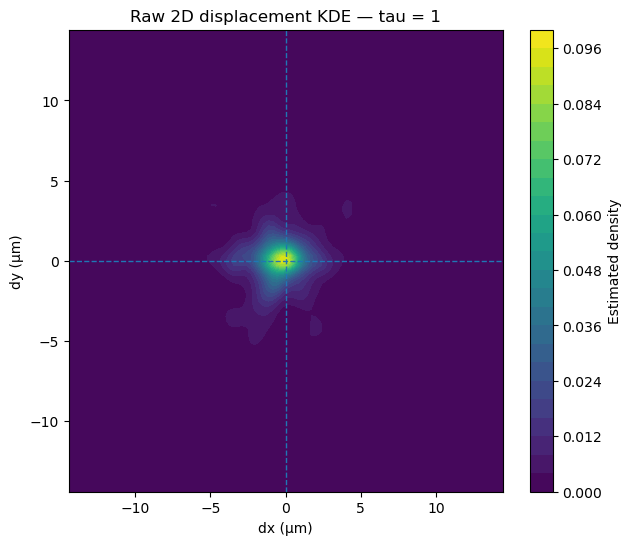

In [49]:
raw_tau1_points = get_displacement_points(
    steps_analysis,
    representation="raw",
    tau_frames=1,
)

comoving_tau1_points = get_displacement_points(
    steps_analysis,
    representation="comoving",
    tau_frames=1,
)

tau1_bandwidth = shared_bandwidth_2d(
    raw_tau1_points,
    comoving_tau1_points,
)

tau1_x_grid, tau1_y_grid = (
    make_symmetric_2d_grid(
        raw_tau1_points,
        comoving_tau1_points,
        bandwidth=tau1_bandwidth,
        n_grid=101,
    )
)

xx, yy, raw_tau1_density = (
    evaluate_kde_2d(
        raw_tau1_points,
        tau1_x_grid,
        tau1_y_grid,
        tau1_bandwidth,
    )
)

plt.figure(figsize=(7, 6))

plt.contourf(
    xx,
    yy,
    raw_tau1_density,
    levels=25,
)

plt.axvline(
    0,
    linestyle="--",
    linewidth=1,
)

plt.axhline(
    0,
    linestyle="--",
    linewidth=1,
)

plt.xlabel("dx (µm)")
plt.ylabel("dy (µm)")
plt.title(
    "Raw 2D displacement KDE — tau = 1"
)

plt.colorbar(
    label="Estimated density"
)

plt.show()

## Robustness to KDE bandwidth

The inversion-asymmetry estimate depends on the KDE smoothing bandwidth.

To determine whether the qualitative raw-versus-co-moving result is driven
by a particular smoothing choice, the analysis is repeated using:

- 0.5 × the baseline bandwidth;
- 1.0 × the baseline bandwidth;
- 2.0 × the baseline bandwidth.

The purpose is not to optimize the bandwidth exhaustively, but to test whether
the main qualitative conclusion is robust to reasonable changes in smoothing.

In [50]:
def compute_asymmetry_pair(
    raw_points: np.ndarray,
    comoving_points: np.ndarray,
    tau_frames: int,
    bandwidth_multiplier: float = 1.0,
    n_grid: int = 101,
) -> pd.DataFrame:
    """
    Calculate raw and co-moving inversion asymmetry
    using a shared KDE bandwidth and symmetric grid.
    """

    baseline_bandwidth = shared_bandwidth_2d(
        raw_points,
        comoving_points,
    )

    bandwidth = (
        baseline_bandwidth
        * bandwidth_multiplier
    )

    x_grid, y_grid = make_symmetric_2d_grid(
        raw_points,
        comoving_points,
        bandwidth=bandwidth,
        n_grid=n_grid,
    )

    records = []

    for representation, points in [
        ("raw", raw_points),
        ("comoving", comoving_points),
    ]:

        _, _, density = evaluate_kde_2d(
            points,
            x_grid,
            y_grid,
            bandwidth,
        )

        asymmetry, grid_mass = (
            inversion_asymmetry_index(
                density,
                x_grid,
                y_grid,
            )
        )

        records.append(
            {
                "tau_frames": tau_frames,
                "representation": representation,
                "bandwidth_multiplier": bandwidth_multiplier,
                "bandwidth_um": bandwidth,
                "grid_mass": grid_mass,
                "inversion_asymmetry_nats": asymmetry,
            }
        )

    return pd.DataFrame(records)

In [51]:
BANDWIDTH_MULTIPLIERS = [
    0.5,
    1.0,
    2.0,
]

bandwidth_sensitivity_tables = []

for tau_frames in TAUS:

    raw_points = get_displacement_points(
        steps_analysis,
        representation="raw",
        tau_frames=tau_frames,
    )

    comoving_points = get_displacement_points(
        steps_analysis,
        representation="comoving",
        tau_frames=tau_frames,
    )

    for multiplier in BANDWIDTH_MULTIPLIERS:

        result = compute_asymmetry_pair(
            raw_points=raw_points,
            comoving_points=comoving_points,
            tau_frames=tau_frames,
            bandwidth_multiplier=multiplier,
            n_grid=101,
        )

        bandwidth_sensitivity_tables.append(
            result
        )

bandwidth_sensitivity = pd.concat(
    bandwidth_sensitivity_tables,
    ignore_index=True,
)

display(bandwidth_sensitivity)

,tau_frames,representation,bandwidth_multiplier,bandwidth_um,grid_mass,inversion_asymmetry_nats
0,1,raw,0.5,0.257984,0.999999,1.632668
1,1,comoving,0.5,0.257984,1.000000,1.287617
2,1,raw,1.0,0.515968,0.999998,0.682156
3,1,comoving,1.0,0.515968,0.999999,0.482956
4,1,raw,2.0,1.031936,0.999996,0.268023
5,1,comoving,2.0,1.031936,0.999998,0.159777
6,2,raw,0.5,0.477840,0.999999,1.379156
7,2,comoving,0.5,0.477840,0.999999,1.104216
8,2,raw,1.0,0.955681,0.999998,0.568221
9,2,comoving,1.0,0.955681,0.999997,0.437690


In [52]:
bandwidth_comparison = (
    bandwidth_sensitivity
    .pivot(
        index=[
            "tau_frames",
            "bandwidth_multiplier",
        ],
        columns="representation",
        values="inversion_asymmetry_nats",
    )
    .reset_index()
)

bandwidth_comparison[
    "raw_minus_comoving"
] = (
    bandwidth_comparison["raw"]
    - bandwidth_comparison["comoving"]
)

display(bandwidth_comparison)

representation,tau_frames,bandwidth_multiplier,comoving,raw,raw_minus_comoving
0,1,0.5,1.287617,1.632668,0.345051
1,1,1.0,0.482956,0.682156,0.199199
2,1,2.0,0.159777,0.268023,0.108246
3,2,0.5,1.104216,1.379156,0.274940
4,2,1.0,0.437690,0.568221,0.130532
5,2,2.0,0.126871,0.217927,0.091055
6,4,0.5,1.423834,1.771585,0.347750
7,4,1.0,0.541848,0.792825,0.250977
8,4,2.0,0.176811,0.302440,0.125630


## Cell-level bootstrap uncertainty

Displacement observations from the same cell are not independent.

Therefore, uncertainty is estimated using a cell-level bootstrap rather than
resampling individual displacement rows independently.

For each temporal lag:

1. the cells contributing to that lag are identified;
2. cells are sampled with replacement;
3. all displacement observations from each selected cell are retained;
4. the raw and co-moving representations use the same resampled cells;
5. the inversion-asymmetry metric is recalculated.

This provides an exploratory estimate of sampling uncertainty while preserving
within-cell clustering more appropriately than a naive step-level bootstrap.

In [53]:
def bootstrap_cell_points(
    raw_tau: pd.DataFrame,
    comoving_tau: pd.DataFrame,
    rng: np.random.Generator,
):
    """
    Resample cells with replacement and return paired
    raw and co-moving displacement point arrays.
    """

    raw_cells = set(
        raw_tau["cell_id"].unique()
    )

    comoving_cells = set(
        comoving_tau["cell_id"].unique()
    )

    common_cells = sorted(
        raw_cells.intersection(
            comoving_cells
        )
    )

    sampled_cells = rng.choice(
        common_cells,
        size=len(common_cells),
        replace=True,
    )

    raw_blocks = []
    comoving_blocks = []

    for cell_id in sampled_cells:

        raw_block = (
            raw_tau
            .loc[
                raw_tau["cell_id"].eq(cell_id),
                ["dx_um", "dy_um"],
            ]
            .to_numpy()
        )

        comoving_block = (
            comoving_tau
            .loc[
                comoving_tau["cell_id"].eq(cell_id),
                ["dx_um", "dy_um"],
            ]
            .to_numpy()
        )

        raw_blocks.append(
            raw_block
        )

        comoving_blocks.append(
            comoving_block
        )

    raw_points = np.vstack(
        raw_blocks
    )

    comoving_points = np.vstack(
        comoving_blocks
    )

    return (
        raw_points,
        comoving_points,
    )

In [54]:
N_BOOTSTRAP = 100
RANDOM_SEED = 2026

rng = np.random.default_rng(
    RANDOM_SEED
)

bootstrap_records = []

for tau_frames in TAUS:

    raw_tau = (
        steps_raw
        .loc[
            steps_raw["tau_frames"]
            .eq(tau_frames)
        ]
        .copy()
    )

    comoving_tau = (
        steps_comoving
        .loc[
            steps_comoving["tau_frames"]
            .eq(tau_frames)
        ]
        .copy()
    )

    for bootstrap_id in range(
        N_BOOTSTRAP
    ):

        (
            raw_points,
            comoving_points,
        ) = bootstrap_cell_points(
            raw_tau,
            comoving_tau,
            rng,
        )

        result = compute_asymmetry_pair(
            raw_points=raw_points,
            comoving_points=comoving_points,
            tau_frames=tau_frames,
            bandwidth_multiplier=1.0,
            n_grid=81,
        )

        raw_value = (
            result
            .loc[
                result["representation"]
                .eq("raw"),
                "inversion_asymmetry_nats",
            ]
            .iloc[0]
        )

        comoving_value = (
            result
            .loc[
                result["representation"]
                .eq("comoving"),
                "inversion_asymmetry_nats",
            ]
            .iloc[0]
        )

        bootstrap_records.append(
            {
                "bootstrap_id": bootstrap_id,
                "tau_frames": tau_frames,
                "raw": raw_value,
                "comoving": comoving_value,
                "raw_minus_comoving": (
                    raw_value
                    - comoving_value
                ),
            }
        )

bootstrap_results = pd.DataFrame(
    bootstrap_records
)

print(
    "Bootstrap replicates:",
    len(bootstrap_results)
)

display(
    bootstrap_results.head()
)

Bootstrap replicates: 300


,bootstrap_id,tau_frames,raw,comoving,raw_minus_comoving
0,0,1,1.407656,0.916564,0.491092
1,1,1,0.943179,0.625594,0.317585
2,2,1,0.744656,0.557731,0.186925
3,3,1,1.290416,0.991527,0.298889
4,4,1,1.319101,0.975800,0.343301


In [55]:
bootstrap_summary_records = []

for tau_frames in TAUS:

    subset = (
        bootstrap_results
        .loc[
            bootstrap_results["tau_frames"]
            .eq(tau_frames)
        ]
    )

    for metric in [
        "raw",
        "comoving",
        "raw_minus_comoving",
    ]:

        values = subset[metric]

        bootstrap_summary_records.append(
            {
                "tau_frames": tau_frames,
                "metric": metric,
                "bootstrap_mean": values.mean(),
                "ci025": values.quantile(0.025),
                "ci975": values.quantile(0.975),
            }
        )

bootstrap_summary = pd.DataFrame(
    bootstrap_summary_records
)

display(bootstrap_summary)

,tau_frames,metric,bootstrap_mean,ci025,ci975
0,1,raw,0.976148,0.596142,1.501263
1,1,comoving,0.728371,0.443056,1.202298
2,1,raw_minus_comoving,0.247777,0.041472,0.550427
3,2,raw,0.821971,0.410549,1.441254
4,2,comoving,0.653052,0.383908,1.109211
5,2,raw_minus_comoving,0.168919,-0.082389,0.524471
6,4,raw,1.181971,0.605889,2.008957
7,4,comoving,0.918295,0.436351,1.529409
8,4,raw_minus_comoving,0.263675,-0.055736,0.677328


## Inversion-symmetric null control

A positive inversion-asymmetry estimate can arise even when the underlying
distribution is symmetric, because the dataset contains a finite number of
observations and the probability density is estimated numerically.

To estimate this finite-sample and KDE background, we construct a simple
inversion-symmetric null model.

For each observed displacement vector,

$$
\Delta \mathbf{r}
=
(\Delta x,\Delta y)
$$

we randomly choose, with equal probability, either the original vector

$$
\Delta \mathbf{r}
$$

or its spatially inverted counterpart

$$
-\Delta \mathbf{r}
=
(-\Delta x,-\Delta y)
$$

Thus, each displacement has a 50% probability of being retained and a 50%
probability of being inverted.

Importantly, the entire two-dimensional vector is inverted together:

$$
(\Delta x,\Delta y)
\longrightarrow
(-\Delta x,-\Delta y)
$$

The signs of `dx` and `dy` are **not** randomized independently.

This procedure removes systematic preference for one spatial direction over
its inverted counterpart while preserving the observed displacement
magnitudes and much of the empirical sample structure.

The resulting null distribution provides an exploratory reference for the
amount of inversion asymmetry that can arise from finite sampling and density
estimation alone.

It is used as a diagnostic control rather than as a definitive formal
hypothesis test.

In [56]:
N_NULL = 100

null_rng = np.random.default_rng(
    RANDOM_SEED + 1
)

null_records = []

for tau_frames in TAUS:

    raw_points = get_displacement_points(
        steps_analysis,
        representation="raw",
        tau_frames=tau_frames,
    )

    comoving_points = get_displacement_points(
        steps_analysis,
        representation="comoving",
        tau_frames=tau_frames,
    )

    bandwidth = shared_bandwidth_2d(
        raw_points,
        comoving_points,
    )

    x_grid, y_grid = make_symmetric_2d_grid(
        raw_points,
        comoving_points,
        bandwidth=bandwidth,
        n_grid=81,
    )

    for representation, points in [
        ("raw", raw_points),
        ("comoving", comoving_points),
    ]:

        for null_id in range(
            N_NULL
        ):

            signs = null_rng.choice(
                [-1.0, 1.0],
                size=(len(points), 1),
            )

            null_points = (
                points * signs
            )

            _, _, null_density = evaluate_kde_2d(
                null_points,
                x_grid,
                y_grid,
                bandwidth,
            )

            null_asymmetry, _ = (
                inversion_asymmetry_index(
                    null_density,
                    x_grid,
                    y_grid,
                )
            )

            null_records.append(
                {
                    "tau_frames": tau_frames,
                    "representation": representation,
                    "null_id": null_id,
                    "null_asymmetry_nats": null_asymmetry,
                }
            )

null_results = pd.DataFrame(
    null_records
)

print(
    "Null simulations:",
    len(null_results)
)

Null simulations: 600


In [57]:
null_summary = (
    null_results
    .groupby(
        [
            "tau_frames",
            "representation",
        ]
    )
    .agg(
        null_mean=(
            "null_asymmetry_nats",
            "mean",
        ),
        null_q95=(
            "null_asymmetry_nats",
            lambda values:
                values.quantile(0.95),
        ),
    )
    .reset_index()
)

observed_for_null = (
    asymmetry_summary[
        [
            "tau_frames",
            "representation",
            "inversion_asymmetry_nats",
        ]
    ]
    .rename(
        columns={
            "inversion_asymmetry_nats":
                "observed_asymmetry"
        }
    )
)

null_comparison = (
    observed_for_null
    .merge(
        null_summary,
        on=[
            "tau_frames",
            "representation",
        ],
        how="left",
        validate="one_to_one",
    )
)

null_comparison[
    "observed_minus_null_mean"
] = (
    null_comparison[
        "observed_asymmetry"
    ]
    - null_comparison[
        "null_mean"
    ]
)

null_comparison[
    "above_null_q95"
] = (
    null_comparison[
        "observed_asymmetry"
    ]
    > null_comparison[
        "null_q95"
    ]
)

display(null_comparison)

,tau_frames,representation,observed_asymmetry,null_mean,null_q95,observed_minus_null_mean,above_null_q95
0,1,raw,0.682156,0.420430,0.538181,0.261726,True
1,1,comoving,0.482956,0.389444,0.517069,0.093513,False
2,2,raw,0.568221,0.229393,0.318185,0.338828,True
3,2,comoving,0.437690,0.218620,0.288457,0.219070,True
4,4,raw,0.792825,0.215770,0.319931,0.577055,True
5,4,comoving,0.541848,0.229415,0.353751,0.312434,True


In [58]:
CONSTANT_Y_CELLS = [
    2,
    12,
    14,
    30,
    31,
    26,
    21,
]

steps_without_constant_y = (
    steps_analysis
    .loc[
        ~steps_analysis["cell_id"]
        .isin(CONSTANT_Y_CELLS)
    ]
    .copy()
)

print(
    "Rows with all cells:",
    len(steps_analysis),
)

print(
    "Rows after excluding constant-y cells:",
    len(steps_without_constant_y),
)

Rows with all cells: 2348
Rows after excluding constant-y cells: 1986


In [59]:
constant_y_sensitivity_records = []

for tau_frames in TAUS:

    raw_all = get_displacement_points(
        steps_analysis,
        "raw",
        tau_frames,
    )

    comoving_all = get_displacement_points(
        steps_analysis,
        "comoving",
        tau_frames,
    )

    all_result = compute_asymmetry_pair(
        raw_points=raw_all,
        comoving_points=comoving_all,
        tau_frames=tau_frames,
        bandwidth_multiplier=1.0,
        n_grid=101,
    )

    raw_filtered = get_displacement_points(
        steps_without_constant_y,
        "raw",
        tau_frames,
    )

    comoving_filtered = get_displacement_points(
        steps_without_constant_y,
        "comoving",
        tau_frames,
    )

    filtered_result = compute_asymmetry_pair(
        raw_points=raw_filtered,
        comoving_points=comoving_filtered,
        tau_frames=tau_frames,
        bandwidth_multiplier=1.0,
        n_grid=101,
    )

    for representation in [
        "raw",
        "comoving",
    ]:

        all_value = (
            all_result
            .loc[
                all_result["representation"]
                .eq(representation),
                "inversion_asymmetry_nats",
            ]
            .iloc[0]
        )

        filtered_value = (
            filtered_result
            .loc[
                filtered_result[
                    "representation"
                ].eq(representation),
                "inversion_asymmetry_nats",
            ]
            .iloc[0]
        )

        constant_y_sensitivity_records.append(
            {
                "tau_frames": tau_frames,
                "representation": representation,
                "all_tracks": all_value,
                "without_constant_y": filtered_value,
                "difference": (
                    filtered_value
                    - all_value
                ),
                "relative_change": (
                    (
                        filtered_value
                        - all_value
                    )
                    / all_value
                ),
            }
        )

constant_y_sensitivity = pd.DataFrame(
    constant_y_sensitivity_records
)

display(constant_y_sensitivity)

,tau_frames,representation,all_tracks,without_constant_y,difference,relative_change
0,1,raw,0.682156,0.648158,-0.033997,-0.049838
1,1,comoving,0.482956,0.460205,-0.022752,-0.047110
2,2,raw,0.568221,0.474558,-0.093664,-0.164837
3,2,comoving,0.437690,0.359868,-0.077821,-0.177800
4,4,raw,0.792825,0.667167,-0.125658,-0.158494
5,4,comoving,0.541848,0.438515,-0.103334,-0.190706


In [60]:
phase5_final = (
    asymmetry_summary[
        [
            "tau_frames",
            "representation",
            "n_steps",
            "inversion_asymmetry_nats",
        ]
    ]
    .merge(
        null_comparison[
            [
                "tau_frames",
                "representation",
                "null_mean",
                "null_q95",
                "above_null_q95",
            ]
        ],
        on=[
            "tau_frames",
            "representation",
        ],
        how="left",
    )
    .merge(
        constant_y_sensitivity[
            [
                "tau_frames",
                "representation",
                "without_constant_y",
                "relative_change",
            ]
        ],
        on=[
            "tau_frames",
            "representation",
        ],
        how="left",
    )
)

display(phase5_final)

,tau_frames,representation,n_steps,inversion_asymmetry_nats,null_mean,null_q95,above_null_q95,without_constant_y,relative_change
0,1,raw,433,0.682156,0.420430,0.538181,True,0.648158,-0.049838
1,1,comoving,433,0.482956,0.389444,0.517069,False,0.460205,-0.047110
2,2,raw,398,0.568221,0.229393,0.318185,True,0.474558,-0.164837
3,2,comoving,398,0.437690,0.218620,0.288457,True,0.359868,-0.177800
4,4,raw,343,0.792825,0.215770,0.319931,True,0.667167,-0.158494
5,4,comoving,343,0.541848,0.229415,0.353751,True,0.438515,-0.190706


## Phase 5 conclusion

Phase 5 established a reproducible exploratory workflow for characterizing
cell-displacement distributions and quantifying their spatial inversion
asymmetry.

The analysis included:

- empirical one-dimensional displacement distributions;
- Freedman-Diaconis data-driven histogram binning;
- one-dimensional kernel-density estimation;
- two-dimensional KDE estimation of p(dx, dy);
- comparison of p(Delta) with p(-Delta);
- raw versus co-moving analysis;
- KDE-bandwidth sensitivity;
- cell-level bootstrap uncertainty;
- an inversion-symmetrized null control;
- and a sensitivity analysis excluding constant-y tracks.

### Main observations

The raw displacement distributions showed measurable spatial inversion
asymmetry at all three analyzed lags.

Using the baseline two-dimensional KDE estimator, the inversion-asymmetry
values were approximately:

| tau (frames) | Raw | Co-moving |
|---|---:|---:|
| 1 | 0.682 | 0.483 |
| 2 | 0.568 | 0.438 |
| 4 | 0.793 | 0.542 |

The co-moving representation produced lower inversion-asymmetry estimates at
all three lags, indicating that the frame-wise common translational component
contributes to the asymmetry observed in the raw trajectories.

This qualitative ordering was preserved when the KDE bandwidth was varied
between 0.5, 1, and 2 times the baseline bandwidth. The absolute magnitude of
the asymmetry estimate, however, depended substantially on bandwidth and
should therefore not be interpreted as a uniquely determined physical
constant.

Cell-level bootstrap analysis showed that the raw-minus-co-moving difference
was consistently positive for tau = 1 within the exploratory bootstrap
interval, whereas the corresponding intervals for tau = 2 and tau = 4
included zero. Thus, the magnitude of the raw-versus-co-moving difference at
longer lags remains sensitive to the particular cells represented in the
sample.

A simple inversion-symmetrized null model showed that the raw estimate at
tau = 1 exceeded the 95th percentile of the null distribution, whereas the
co-moving estimate at tau = 1 did not. At tau = 2 and tau = 4, both raw and
co-moving estimates exceeded the corresponding null 95th percentiles.

Seven tracks with constant raw y coordinates were identified during
exploratory diagnostics. Excluding these tracks reduced the estimated
asymmetry by approximately 5% at tau = 1 and by roughly 16-19% at the longer
lags, but did not remove the overall qualitative pattern. These tracks are
therefore treated as a documented data-quality limitation rather than as a
reason to stop the exploratory analysis.

### Interpretation

The results support the presence of single-displacement spatial inversion
asymmetry in this dataset and show that common population-level translation
accounts for part, but not necessarily all, of that asymmetry.

These findings are exploratory and hypothesis-generating. They do not by
themselves establish trajectory-level time irreversibility, biological entropy
production, or a thermodynamic arrow of time.

The next phase will therefore move from single-displacement inversion to
ordered multi-step sequences, where the true time-reversal operation also
reverses temporal order.

In [61]:
# Final Phase 5 validation

assert set(
    phase5_final["tau_frames"]
) == {1, 2, 4}

assert set(
    phase5_final["representation"]
) == {
    "raw",
    "comoving",
}

assert len(
    phase5_final
) == 6

assert (
    phase5_final[
        "inversion_asymmetry_nats"
    ] > 0
).all()

assert (
    asymmetry_summary[
        "grid_mass"
    ].between(
        0.99,
        1.01,
    )
).all()

baseline_bandwidth_rows = (
    bandwidth_comparison
    .loc[
        bandwidth_comparison[
            "bandwidth_multiplier"
        ].eq(1.0)
    ]
)

assert (
    baseline_bandwidth_rows[
        "raw_minus_comoving"
    ] > 0
).all()

print(
    "Phase 5 validation: PASSED"
)

display(
    phase5_final
)

Phase 5 validation: PASSED


,tau_frames,representation,n_steps,inversion_asymmetry_nats,null_mean,null_q95,above_null_q95,without_constant_y,relative_change
0,1,raw,433,0.682156,0.420430,0.538181,True,0.648158,-0.049838
1,1,comoving,433,0.482956,0.389444,0.517069,False,0.460205,-0.047110
2,2,raw,398,0.568221,0.229393,0.318185,True,0.474558,-0.164837
3,2,comoving,398,0.437690,0.218620,0.288457,True,0.359868,-0.177800
4,4,raw,343,0.792825,0.215770,0.319931,True,0.667167,-0.158494
5,4,comoving,343,0.541848,0.229415,0.353751,True,0.438515,-0.190706
